# Extracción de perfiles del International Multi-Tokamak Confinement Profile Database

In [1]:
import MDSplus
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Conexión a la base de Datos
conn = MDSplus.Connection('tokamak-profiledb.ccfe.ac.uk')
conn.openTree('pr08_rtp', 97053056)

In [3]:
#amin = conn.get(r'\top.zerod:amin').data()
#rmag = conn.get(r'\top.zerod:rmag').data()
#zmag = conn.get(r'\top.zerod:zmag').data()
#rgeo = conn.get(r'\top.zerod:rgeo').data()

In [4]:
# Obtención de los perfiles T y n como F(r,t)
Te = conn.get(r'\top.twod:te').data()
ne = conn.get(r'\top.twod:ne').data()

In [5]:
t = conn.get(r'dim_of(\top.twod:te,1)').data()
rho = conn.get(r'dim_of(\top.twod:te,0)').data() 

In [6]:
Te_unit = conn.get(r'units_of(\top.twod:te)').data()
ne_unit = conn.get(r'units_of(\top.twod:ne)').data()
t_unit  = conn.get(r'units_of(dim_of(\top.twod:te,1))').data()
r_unit  = conn.get(r'units_of(dim_of(\top.twod:te,0))').data()

In [7]:
That = np.copy((Te - Te.min()) / (Te.max() - Te.min()))
nhat = np.copy((ne - ne.min()) / (ne.max() - ne.min()))

In [8]:
#assert Te.shape == (len(t), len(r)), f"Unexpected Te shape: {Te.shape}, t={len(t)}, r={len(r)}"
#assert ne.shape == (len(t), len(r)), f"Unexpected Te shape: {ne.shape}, t={len(t)}, r={len(r)}"

In [9]:
#t0 = 9.6
#itime = np.argmin(np.abs(t - t0))

In [10]:
#Te_r = Te[itime, :]
#ne_r = ne[itime, :]

In [19]:
That.argmax()
rho[17]

0.425

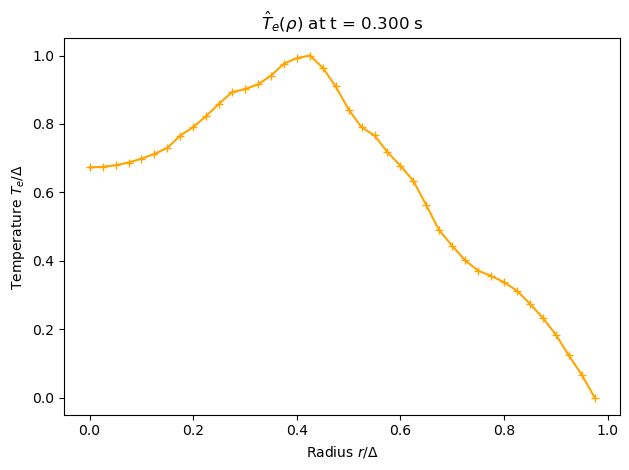

In [11]:
plt.figure()
plt.plot(rho, That, marker='+', linestyle='-', color='orange')
plt.xlabel(r"Radius $r / \Delta$")
plt.ylabel("Temperature $T_e / \Delta$")
plt.title(r"$\hat{T}_e(\rho)$ at t = " + f"{t[0]:.3f} {t_unit}")
plt.tight_layout()
plt.show()

In [12]:
alpha = 5
P = 1/2.5
gamma = 1.0

In [13]:
den = (1 - P) * (1 - rho**2)**alpha + P * np.sqrt(1 - gamma * rho**2)

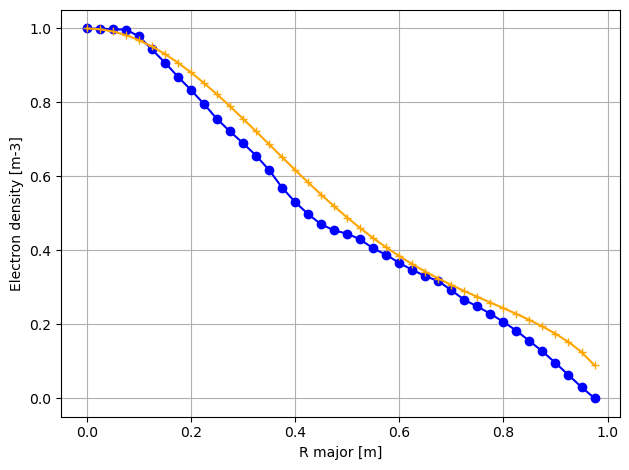

In [20]:
plt.figure()
plt.plot(rho, nhat, marker='o', linestyle='-', color='blue')
plt.plot(rho, den, marker='+', linestyle='-', color='orange')
plt.xlabel(r"R major [m]")
plt.ylabel(f"Electron density [{ne_unit}]")
#plt.title(rf"$n_e$(r) at t = {t[itime]:.3f} {t_unit}")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
with open("fit.dat", "w") as f:
    for i in range(40):
        print(rho[i], den[i], file=f, sep=' ')

In [22]:
import pandas as pd 
df = pd.read_csv('avg_shots.dat', sep=' ', header=None)
r = df[0].to_numpy()
den = df[3].to_numpy()
tmp = df[4].to_numpy()

In [25]:
r[15]

0.375

Fitted parameters:
a = 0.403
b = 5.798
c = 1.000


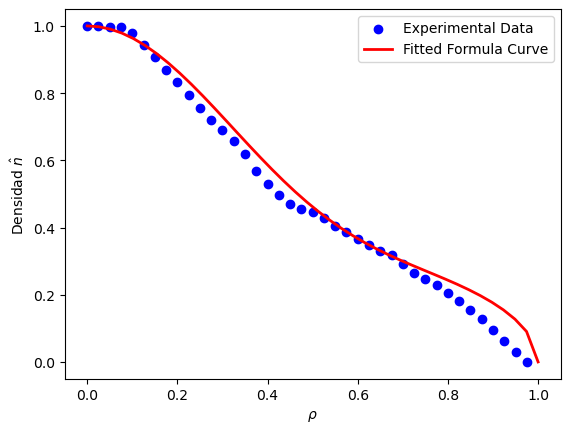

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def n_fit(x, a, b, c):
    return (1 - a) * (1 - x**2) ** b + a * np.sqrt(1 - c * x**2)

lower_bounds = [-np.inf, -np.inf, 0.0]  # Inferior cotes
upper_bounds = [ np.inf, np.inf, 1.0]  # Superior cotes

initial_guess = [0.4, 5.0, 0.5]
popt, pcov = curve_fit(n_fit, r, den, p0=initial_guess, bounds=(lower_bounds, upper_bounds), method='trf', absolute_sigma=True)
a_opt, b_opt, c_opt = popt
print(f"Fitted parameters:\na = {a_opt:.3f}\nb = {b_opt:.3f}\nc = {c_opt:.3f}")

plt.scatter(rho, nhat, color='blue', label='Experimental Data')
x_fit = np.linspace(0, 1, 40)
y_fit = n_fit(x_fit, *popt) 

plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Fitted Formula Curve')
plt.xlabel(r'$\rho$')
plt.ylabel(r'Densidad $\hat{n}$')
plt.legend()
plt.show()

In [ ]:
with open("fit.dat", "w") as f:
    for i in range(40):
        print(x_fit[i], y_fit[i], file=f, sep=' ')

Fitted parameters:
a = 0.918
b = 5.153
c = 0.027


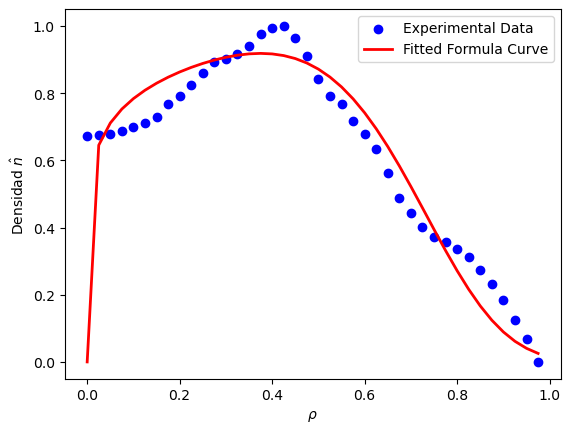

In [33]:
def T_fit(x, a, b, c):
    return a * ( (x / 0.375)**b * np.exp(1 - (x / 0.375)**b))**c

lower_bounds = [0.0, 0.0, 0.0]  # Inferior cotes
upper_bounds = [ 1.0, np.inf, np.inf]  # Superior cotes

initial_guess = [1.0, 0.03, 1.0]
popt, pcov = curve_fit(T_fit, r, tmp, p0=initial_guess, bounds=(lower_bounds, upper_bounds), method='trf', absolute_sigma=True)
a_opt, b_opt, c_opt = popt
print(f"Fitted parameters:\na = {a_opt:.3f}\nb = {b_opt:.3f}\nc = {c_opt:.3f}")

plt.scatter(rho, That, color='blue', label='Experimental Data')
x_fit = np.linspace(0, 0.975, 40)
y_fit = T_fit(x_fit, *popt) 

plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Fitted Formula Curve')
plt.xlabel(r'$\rho$')
plt.ylabel(r'Densidad $\hat{n}$')
plt.legend()
plt.show()